In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib inline

In [48]:
grid = np.linspace(-10, 10, 300)

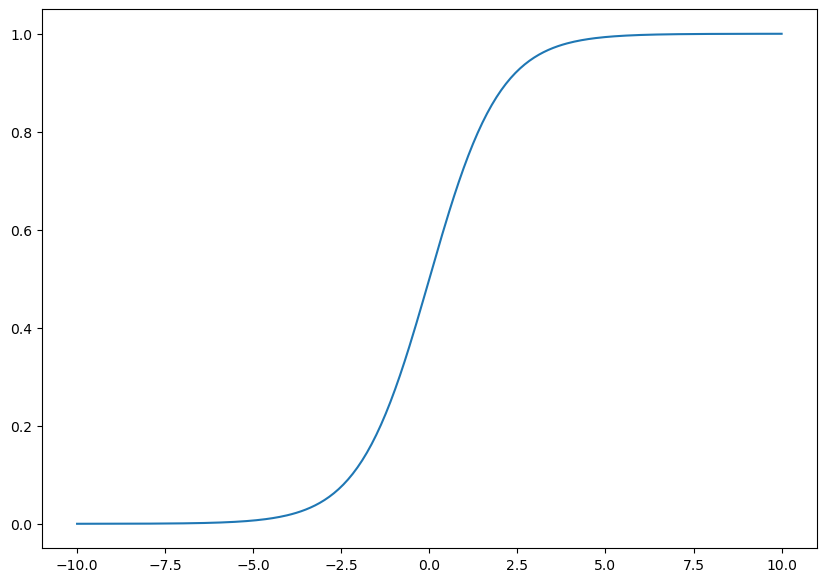

In [49]:
fig = plt.figure(figsize=(10,7))
plt.plot(grid, 1/(1+np.exp(-grid)))

plt.show()

In [50]:
class MyLogisticRegression(object):
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def sigmoid(self, t):
        return 1. / (1+np.exp(-t))

    def grad(self, X, y, y_pred):
        l = X.shape[0]
        grad = X.T @ (y_pred - y) / l
        return grad

    def fit(self, X, y, max_iter=100, lr=0.1):
        X = np.array(X)
        y = np.array(y)

        assert len(y.shape) == 1 and len(X.shape) == 2
        assert X.shape[0] == y.shape[0]

        y = y[:, np.newaxis]
        l, n = X.shape
        X = np.hstack([np.ones([X.shape[0], 1]), X])  # [l, n+1]

        weights = np.random.randn(n+1, 1)
        losses = []

        for num_iter in range(max_iter):
            logits = X @ weights
            y_pred = self.sigmoid(logits)
            grad = self.grad(X, y, y_pred)
            weights -= lr * grad

            loss = self.loss(y, y_pred)
            losses.append(loss)

        self.coef_ = weights[1:]
        self.intercept_ = weights[0]

        return losses

    def predict_proba(self, X):
        X = np.array(X)
        X = np.hstack([np.ones([X.shape[0], 1]), X])
        weights = np.concatenate([self.intercept_.reshape(-1, 1), self.coef_], axis=0)
        logits = (X @ weights)

        return self.sigmoid(logits)

    def predict(self, X, threshold=0.5):
        return self.predict_proba(X) >= threshold
        
    def loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

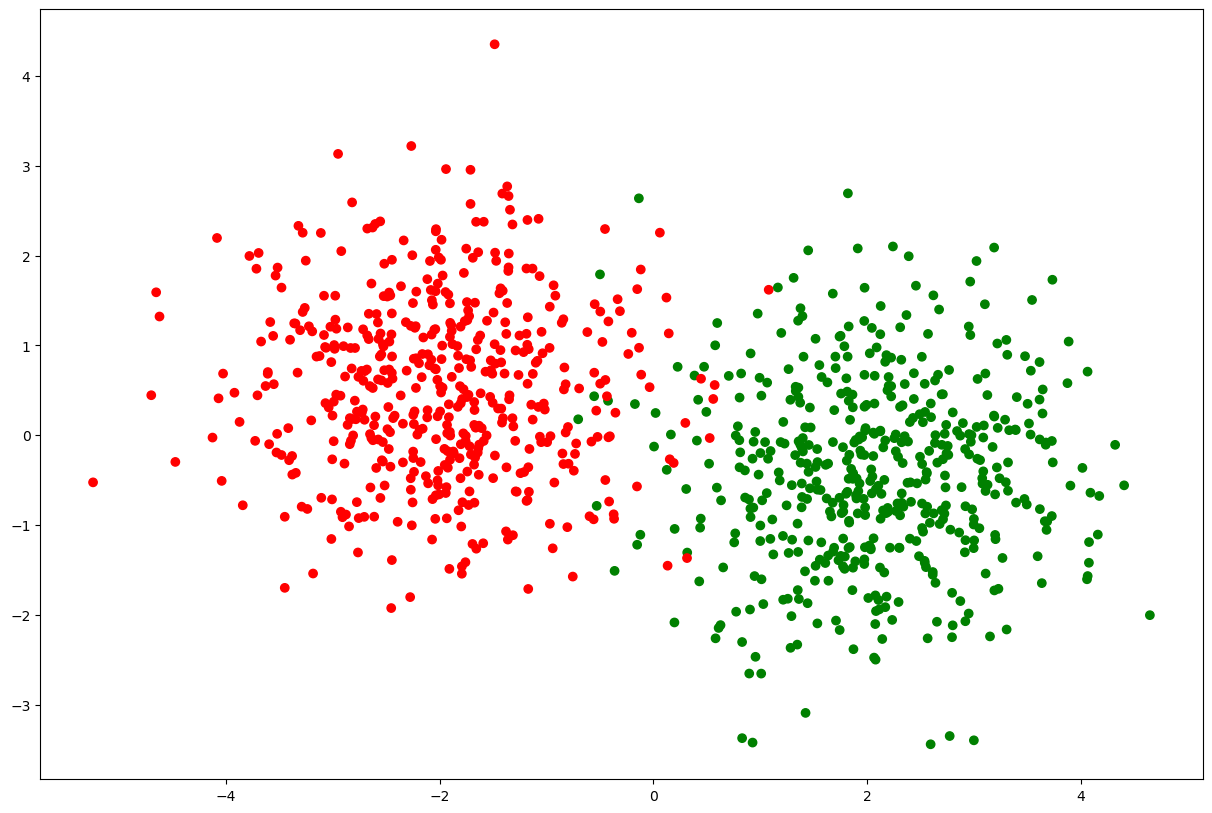

In [51]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000, centers=[[-2,0.5],[2,-0.5]], cluster_std=1, random_state=42)

colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[y == cl] = str(colors[i])

plt.figure(figsize=(15,10))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()

In [52]:
clf = MyLogisticRegression()

losses = clf.fit(X, y, max_iter=1000)

coef, intercept = clf.coef_, clf.intercept_

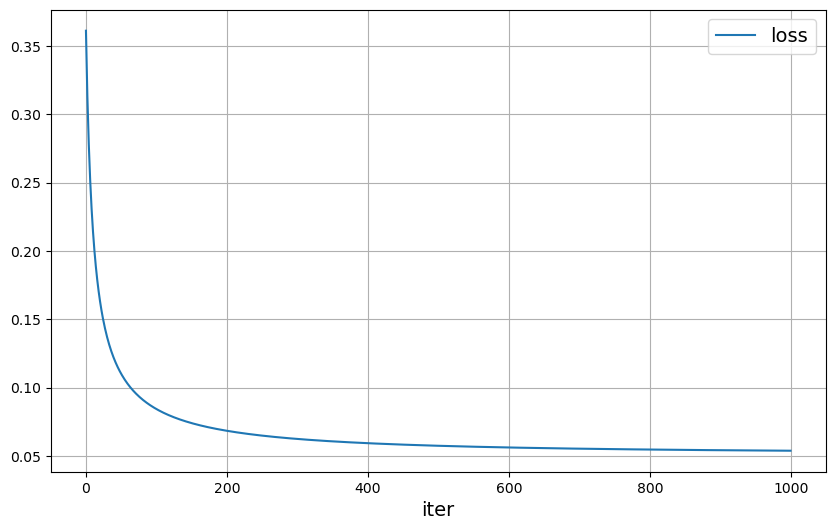

In [65]:
plt.figure(figsize=(10,6))
plt.plot(losses, label='loss')
plt.legend(fontsize=14)
plt.xlabel('iter', fontsize=14)
plt.grid()
plt.show()

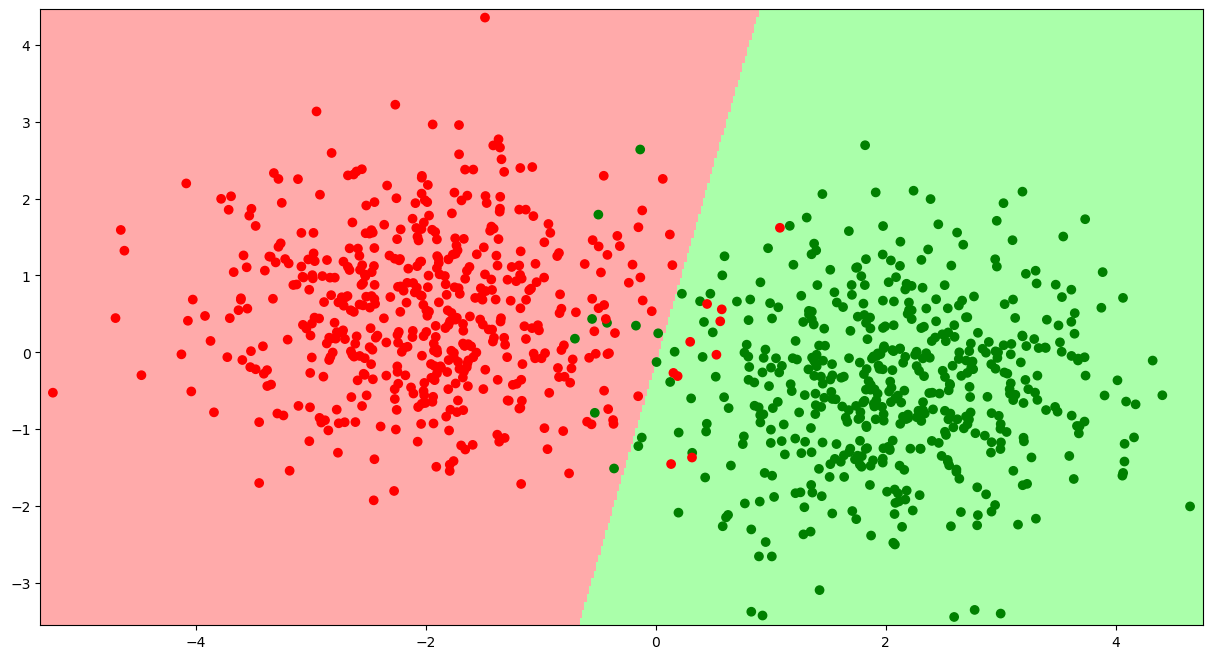

In [67]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

plt.figure(figsize=(15,8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X[:,0]) - eps, np.max(X[:,0]) + eps, 500),
                     np.linspace(np.min(X[:,1]) - eps, np.max(X[:,1]) + eps, 500))


Z = clf.predict(np.stack([xx.ravel(), yy.ravel()]).T)

Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()